# Radiative Background — +Y / -Y Radiators

Layer 3 of 3. Loads view factor data and solar panel temperatures, computes the full radiative background at the radiator surfaces (Earth IR + solar panel IR + direct solar + albedo), and produces animated patch-resolved figures.

**Requires:** `outputs/viewfactors.npz` and `outputs/panel_temperatures.npz`.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from geometry import RealizedGeometry
from geometry.CubeSat.inspect import surface_by_normal
from thermal import (
    RADIATOR_ALPHA_SOLAR, RADIATOR_EPSILON,
    SOLAR_PANEL_CELL_EPSILON, SOLAR_PANEL_BACK_COLD,
    radiative_background, shroud_temperature,
    load_temperatures,
)
from viewfactor import load_profiles
from plots import radiator_heatmap

# ── Paths ──────────────────────────────────────────────────────────────────
GEOMETRY_FILE  = Path('outputs/spacecraft.json')
VF_NPZ         = Path('outputs/viewfactors.npz')
PANEL_TEMP_NPZ = Path('outputs/panel_temperatures.npz')
# ── Configure ──────────────────────────────────────────────────────────────────
sample = 60

In [2]:
# ── Load all data ──────────────────────────────────────────────────────────
realized        = RealizedGeometry.from_json(GEOMETRY_FILE)
profiles, _meta = load_profiles(VF_NPZ)
panel_temps     = load_temperatures(PANEL_TEMP_NPZ)
by_name         = {p.surface_name: p for p in profiles}

plus_y  = surface_by_normal(realized, [0.0,  1.0, 0.0], tag='bus')
minus_y = surface_by_normal(realized, [0.0, -1.0, 0.0], tag='bus')

panel_fronts = sorted(
    [s for s in realized.by_tag('solar_panel')
     if np.allclose(s.normal, [0.0, 0.0, 1.0], atol=1e-9)],
    key=lambda s: float(s.center[1]),
)

u_deg   = np.degrees(profiles[0].u)
eclipse = profiles[0].eclipse
print(f'Loaded {len(profiles)} profiles, {len(u_deg)} orbit samples')

Loaded 14 profiles, 410 orbit samples


In [3]:
# ── Area-weighted solar array temperature traces ───────────────────────────
panel_areas = np.array([s.width * s.height for s in panel_fronts])

def array_mean(bracket):
    traces = np.stack([panel_temps[s.name][bracket].mean(axis=(1, 2)) for s in panel_fronts])
    return np.average(traces, axis=0, weights=panel_areas)

array_temp = {b: array_mean(b) for b in ('hot', 'cold')}

# ── Full radiative background + shroud temperature ─────────────────────────
# HOT bracket: high panel emittance (front-face cell dominant)
# COLD bracket: low panel emittance (Surtec 650 back-face dominant)
panel_eps = {'hot': SOLAR_PANEL_CELL_EPSILON, 'cold': SOLAR_PANEL_BACK_COLD.epsilon}

bg, shroud = {}, {}
for role, surface in [('+Y', plus_y), ('-Y', minus_y)]:
    bg[role], shroud[role] = {}, {}
    for bracket in ('hot', 'cold'):
        b = radiative_background(
            by_name[surface.name],
            solar_panel_temperature_K=array_temp[bracket],
            solar_panel_emittance=panel_eps[bracket],
        )
        bg[role][bracket]     = b
        shroud[role][bracket] = shroud_temperature(
            b, alpha_solar=RADIATOR_ALPHA_SOLAR, epsilon=RADIATOR_EPSILON,
        )
print('Background and shroud temperatures computed.')

Background and shroud temperatures computed.


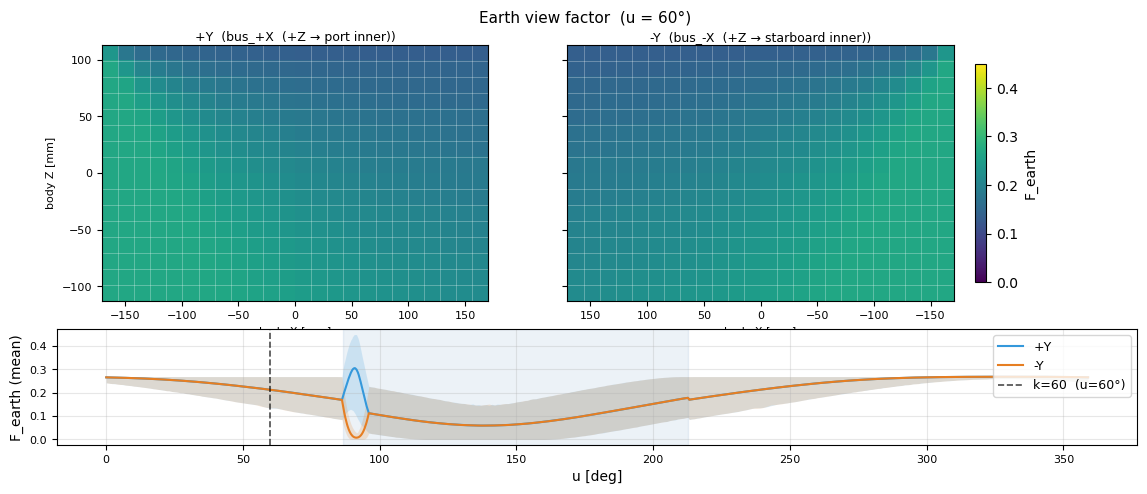

In [4]:
# ── Fig 1: Earth view factor ───────────────────────────────────────────────
radiator_heatmap(
    plus_y, minus_y,
    by_name[plus_y.name].earth_view,
    by_name[minus_y.name].earth_view,
    u_deg, eclipse,
    # gif='outputs/earthVF.gif', fps=12,
    title='Earth view factor',
    cbar_label='F_earth',
    trace_label='F_earth (mean)',
    cmap='viridis', view='unfolded',
    k=60
)
plt.show()

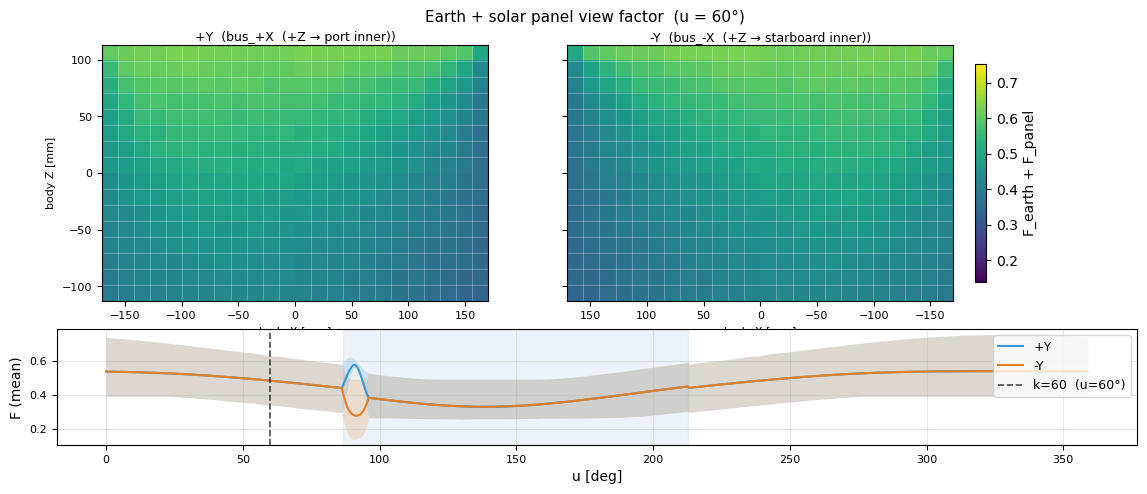

In [5]:
# ── Fig 2: Earth + solar panel view factor ─────────────────────────────────
p_py = by_name[plus_y.name]
p_my = by_name[minus_y.name]
radiator_heatmap(
    plus_y, minus_y,
    p_py.earth_view + p_py.solar_panel_view,
    p_my.earth_view + p_my.solar_panel_view,
    u_deg, eclipse,
    title='Earth + solar panel view factor',
    cbar_label='F_earth + F_panel',
    trace_label='F (mean)',
    cmap='viridis', view='unfolded',
    k=60
)
plt.show()

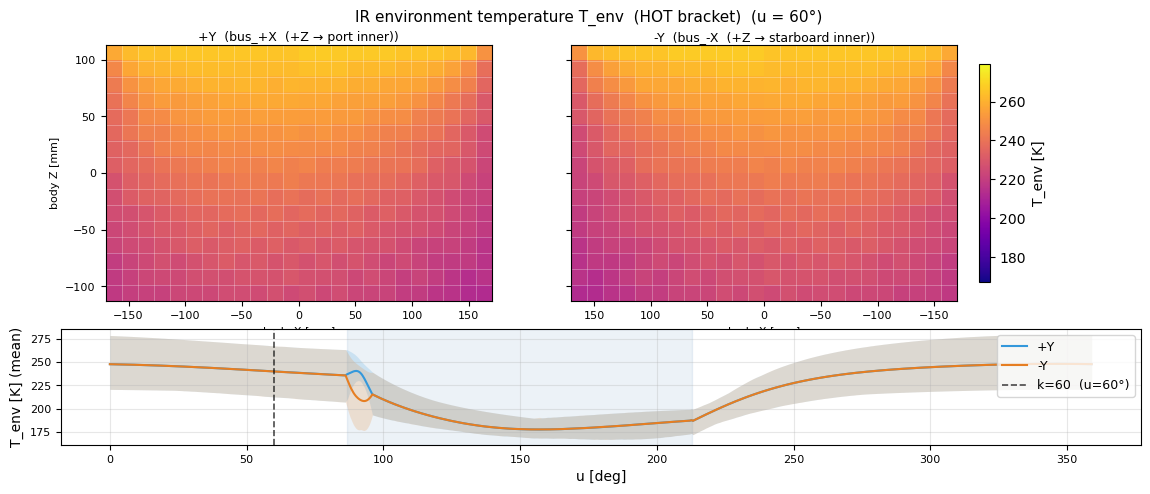

In [6]:
# ── Fig 3: T_env — IR environment temperature (HOT bracket) ───────────────
radiator_heatmap(
    plus_y, minus_y,
    shroud['+Y']['hot'].T_env,
    shroud['-Y']['hot'].T_env,
    u_deg, eclipse,
    title='IR environment temperature T_env  (HOT bracket)',
    cbar_label='T_env [K]',
    trace_label='T_env [K] (mean)',
    cmap='plasma', view='unfolded',
    k=sample,
)
plt.show()

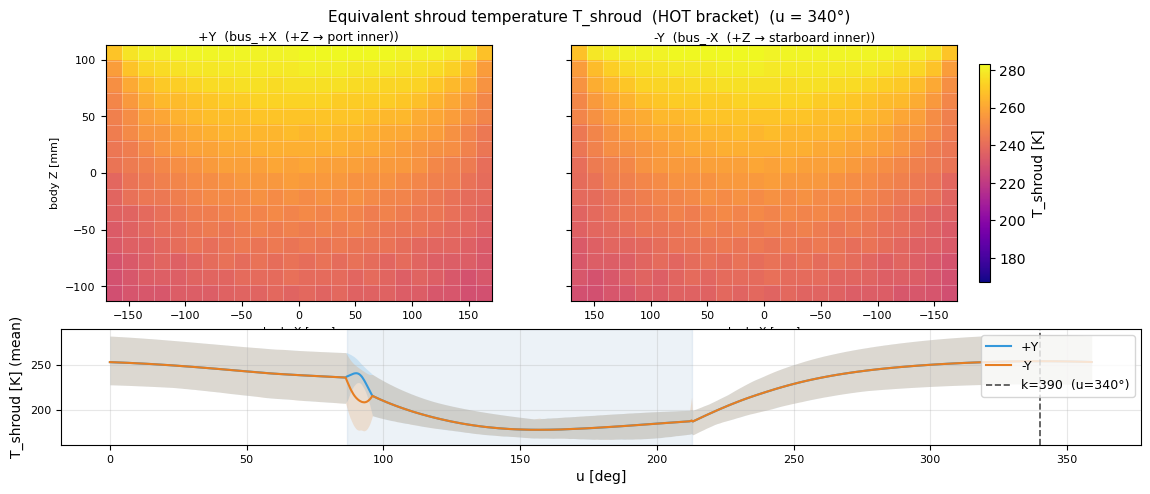

Saved outputs\shroud_hot.gif  (410 frames, 12 fps)


'outputs\\shroud_hot.gif'

In [7]:
# ── Fig 4: T_shroud — full absorbed-flux equivalent temperature (HOT) ──────
radiator_heatmap(
    plus_y, minus_y,
    shroud['+Y']['hot'].T_shroud,
    shroud['-Y']['hot'].T_shroud,
    u_deg, eclipse,
    title='Equivalent shroud temperature T_shroud  (HOT bracket)',
    cbar_label='T_shroud [K]',
    trace_label='T_shroud [K] (mean)',
    cmap='plasma',
)
plt.show()

# Animated GIF version
radiator_heatmap(
    plus_y, minus_y,
    shroud['+Y']['hot'].T_shroud,
    shroud['-Y']['hot'].T_shroud,
    u_deg, eclipse,
    gif='outputs/shroud_hot.gif', fps=12,
    title='Equivalent shroud temperature T_shroud  (HOT bracket)',
    cbar_label='T_shroud [K]',
    trace_label='T_shroud [K] (mean)',
    cmap='plasma',
    k=24
)

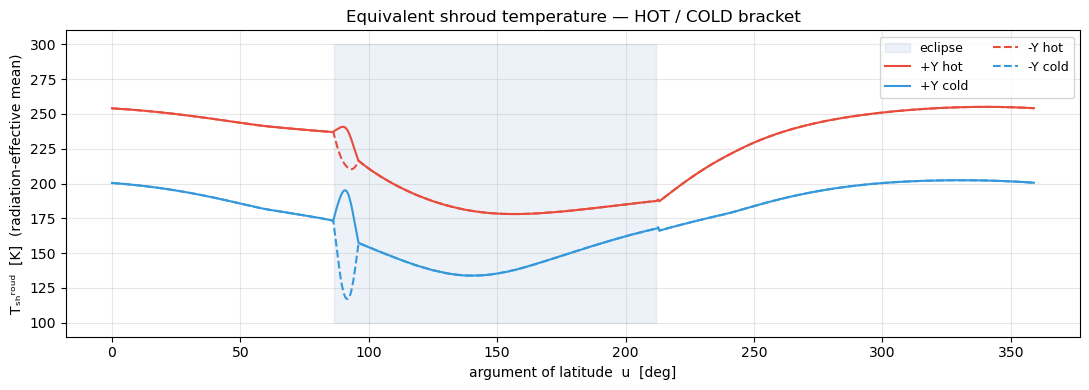

In [8]:
# ── Fig 5: Scalar orbit trace — T_shroud HOT vs COLD bracket ──────────────
# Radiation-power-equivalent scalar: (mean(T^4))^0.25
fig5, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(u_deg, 100, 300, where=eclipse, alpha=0.1, color='steelblue',
                label='eclipse')
for role, ls in [('+Y', '-'), ('-Y', '--')]:
    for bracket, color in [('hot', '#e74c3c'), ('cold', '#3498db')]:
        scalar = shroud[role][bracket].scalar('T_shroud', 'radiative')
        ax.plot(u_deg, scalar, ls, color=color, lw=1.5,
                label=f'{role} {bracket}')

ax.set_xlabel('argument of latitude  u  [deg]')
ax.set_ylabel('T\u209b\u2095\u02b3\u1d52\u1d58\u1d48  [K]  (radiation-effective mean)')
ax.set_title('Equivalent shroud temperature — HOT / COLD bracket')
ax.legend(ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()